# Alias-sampling state preparation

Alias sampling loads a classical probability distribution into a quantum index register. It prepares the index **together with workspace**:

$$
P|0\rangle=\sum_j\sqrt{\widetilde p_j}|j\rangle|g_j\rangle,
\qquad \Pr(\text{index}=j)=\widetilde p_j.
$$

The probabilities $\widetilde p_j$ approximate the requested weights at a chosen binary precision. The index need not be a pure state on its own: the workspace can be entangled with it.

Run from a source checkout with the development dependencies installed. The repository default is little endian.

In [1]:
from math import ceil, log2
import numpy as np
from matplotlib import pyplot as plt
from guppylang import guppy
from guppylang.std.quantum import qubit, discard_array, discard
from guppylang.std.debug import state_output

from guppyalgos.algorithms.state_preparation.alias_sampling import alias_samp_prep
from guppyalgos.algorithms.state_preparation.alias_sampling.alias_table import discretize_distribution
from guppyalgos.primitives.subroutines.fanout import fanout_basic
from guppyalgos.utils import qarray

## 1. Choose the distribution and precision

Use $p=(1/2,1/4,1/4)$. Two index qubits address the three entries, leaving address 3 unused. Two probability bits represent these weights exactly:

$$
n_{\mathrm{index}}=\lceil\log_2L\rceil=2,
\qquad n_{\mathrm{prob}}=\lceil\log_2(1/\epsilon)\rceil=2,
\qquad \epsilon=1/4.
$$

`discretize_distribution` gives the probabilities the finite-precision circuit will load. Smaller `precision` values use more probability bits.

In [2]:
prob_dist = np.array([0.5, 0.25, 0.25])
precision = 0.25
n_index_qubits = ceil(log2(len(prob_dist)))
n_prob_bits = ceil(log2(1 / precision))
loaded_probabilities = discretize_distribution(prob_dist, n_prob_bits)
np.testing.assert_allclose(loaded_probabilities, prob_dist)

## 2. Build and run PREPARE

The alias QROM loads an alternative index and a keep threshold. A uniform comparison register chooses whether to keep the original index or swap in the alternative.

| Register | Purpose |
| :-- | :-- |
| `index_qreg` | The sampled table index. |
| `alternative_qreg` | The alternative index loaded by QROM. |
| `keep_qreg` | The fixed-point keep threshold. |
| `comparison_qreg` | The uniform value compared with that threshold. |
| `comparison_result` | The comparison flag controlling the swap. |

All registers start at zero. `fanout_op` chooses how QROM writes the selected data bits; here it uses basic CNOT fanout.

In [3]:
alias_prepare = alias_samp_prep(prob_dist, precision, fanout_op=fanout_basic)


@guppy
def main() -> None:
    index_qreg = qarray(n_index_qubits)
    alternative_qreg = qarray(n_index_qubits)
    keep_qreg = qarray(n_prob_bits)
    comparison_qreg = qarray(n_prob_bits)
    comparison_result = qubit()
    alias_prepare(
        index_qreg, alternative_qreg, keep_qreg,
        comparison_qreg, comparison_result, False,
    )
    state_output("result_state", index_qreg)

    # This diagnostic is finished; no coherent operation follows.
    discard_array(index_qreg)
    discard_array(alternative_qreg)
    discard_array(keep_qreg)
    discard_array(comparison_qreg)
    discard(comparison_result)


total_qubits = (
    3 * n_index_qubits + 2 * n_prob_bits + 5
    + int(np.ceil((n_index_qubits - 3) / 2))
)
result = main.emulator(total_qubits).with_seed(42).run()

## 3. Check the index probabilities

Trace out the workspace before comparing with the requested distribution:

$$
\Pr(j)=\sum_g|\langle j,g|P|0\rangle|^2.
$$

The simulator represents the reduced index state as a weighted mixture. Sum each component's squared **magnitude**, weighted by its probability; squaring complex amplitudes directly would be incorrect.

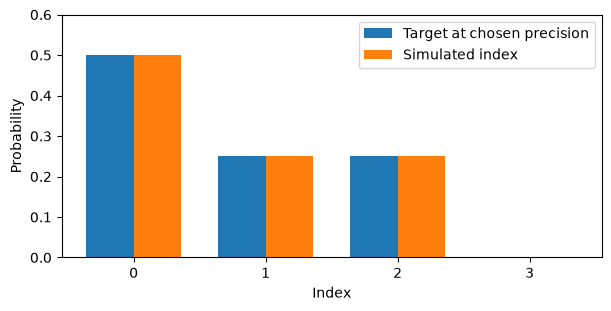

In [4]:
mixture = result.partial_state_dicts()[0]["result_state"].state_distribution()
observed = sum(component.probability * np.abs(component.state)**2 for component in mixture)
expected = np.zeros(2**n_index_qubits)
expected[:len(prob_dist)] = loaded_probabilities
np.testing.assert_allclose(observed, expected, atol=1e-10)

indices = np.arange(len(expected))
fig, axis = plt.subplots(figsize=(6, 3), layout="constrained")
axis.bar(indices - 0.18, expected, width=0.36, label="Target at chosen precision")
axis.bar(indices + 0.18, observed, width=0.36, label="Simulated index")
axis.set(xlabel="Index", ylabel="Probability", xticks=indices, ylim=(0, 0.6))
axis.legend()
plt.show()

## Use alias preparation inside an algorithm

Pass `True` as the final argument to apply UNPREPARE, using the **same registers**. PREPARE followed immediately by UNPREPARE restores the initial state.

After an intervening SELECT, the workspace need not return to zero. Retain it for subsequent coherent operations and include it in any preparation-state reflection. The {doc}`block-encoding demo </examples/block_encoding/block_encoding_demo>` shows the complete PREPARE → SELECT → UNPREPARE composition and how to change the alias-QROM fanout.